<a href="https://colab.research.google.com/github/TienNguyen0712/ai-engineer-journey/blob/main/chapter3_pytorch_computer_vision/flower_classification_cnn_tranfers_learning/01_baseline_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 **Xây dựng, so sánh mạng CNN trong bài toán phân loại ảnh**

## ⚡**Giới thiệu**

### **Mục tiêu**

Notebook này tiếp nối notebook data_prepocessing nơi xây dựng một thuật toán CNN Baseline dùng để phân loại các loại hoa trong bộ dữ liệu `Flowers Recognition` được chia thành 5 nhãn:
- `daisy`: hoa cúc
- `tulip`: hoa tulip
- `rose`: hoa hồng
- `sunflower`: hao hướng dương
- `dandelion`: hoa bồ công anh

**Nhiệm vụ của notebook này bao gồm**:
- Xây dựng mô hình CNN từ ban đầu
- Huấn luyện mô hình sử dụng Pytorch
- Đánh giá hiệu quả phân loại của mô hình
- Trực quan hóa kết quả huấn luyện

### **Tóm tắt các kỹ thuật trong notebook trước**

```
# Chuẩn bị hình ảnh xem trước hình ảnh
Đọc và kiểm tra cấu trúc dữ liệu -> Hiện thị ảnh
-> Chuẩn hóa kích thước ảnh về 224 x 224 -> Áp dụng normalization # Tiền xử lý
-> Thực hiện các phương pháp data augmentation để tăng tính đa dạng dữ liệu -> Tạo Pytorch Dataset và DataLoader # Tạo tính đa dạng
```


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
# Chuẩn bị phần cứng cpu hoặc gpu để huấn luyện mô hình CNN
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


## **Nạp dữ liệu huấn luyện và đánh giá**

In [4]:
# Touch với drive để chạy nooebook00

# from google.colab import drive
# drive.mount('/content/drive')

In [18]:
# Gỡ comment sau khi dã chạy lệnh touch tới drive
# %run /content/drive/MyDrive/Colab_Notebooks/00_data_preprocessing.ipynb # Chạy notebook 1 để xây bộ train_loader, val_loader

In [6]:
train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    shuffle=False
)

In [7]:
print("Size of train data:", len(train_data))
print("Size of val data:", len(val_data))

Size of train data: 3453
Size of val data: 864


## **Xây dựng mô hình CNN**

In [8]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(CustomCNN, self).__init__()

        # ===== Block 1 =====
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )

        # ===== Block 2 =====
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )

        # ===== Block 3 =====
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            nn.Dropout(0.30)
        )

        # ===== Block 4 =====
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.BatchNorm2d(256),
            nn.MaxPool2d(2),
            nn.Dropout(0.30)
        )

        # ===== Global Average Pooling =====
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # ===== Classifier Head =====
        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        x = self.gap(x)
        x = self.classifier(x)

        return x

In [10]:
# Định nghĩa các lớp của model
model = CustomCNN().to(device)

print(model)

CustomCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout(p=0.25, inplace=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 128, ke

In [12]:
# Tạo hàm EarlyStopping
class EarlyStopping:

    def __init__(
        self,
        patience=10,
        min_delta=0,
        path='best_model.pth'
    ):

        self.patience = patience
        self.min_delta = min_delta
        self.path = path

        self.counter = 0
        self.best_loss = None

        self.early_stop = False

    def __call__(self, val_loss, model):

        # First epoch
        if self.best_loss is None:

            self.best_loss = val_loss

            torch.save(
                model.state_dict(),
                self.path
            )

        # Improvement
        elif val_loss < self.best_loss - self.min_delta:

            self.best_loss = val_loss

            self.counter = 0

            torch.save(
                model.state_dict(),
                self.path
            )

            print("Validation loss improved → Model saved")

        # No improvement
        else:

            self.counter += 1

            print(
                f"EarlyStopping counter: "
                f"{self.counter}/{self.patience}"
            )

            if self.counter >= self.patience:

                self.early_stop = True

In [16]:
# Tạo hàm loss
criterion = nn.CrossEntropyLoss()

# Bộ tối ưu
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# Dùng early_stopping
early_stopping = EarlyStopping(
    patience=10,
    min_delta=0.001
)

# scheduler tự động giảm learning rate khi model học chậm lại hoặc val_loss không cải thiện
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

## **Huấn luyện và đánh giá CNN**

In [17]:
train_losses = []
val_losses = []

train_accs = []
val_accs = []

epochs = 48

best_val_loss = float('inf')

patience = 10
counter = 0

for epoch in range(epochs):

    # ================= TRAIN =================
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)

    train_acc = 100 * correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ================= VALIDATION =================
    model.eval()

    val_running_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()

    val_loss = val_running_loss / len(val_loader)

    val_acc = 100 * val_correct / val_total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # ================= LR Scheduler =================
    scheduler.step(val_loss)

    # ================= PRINT =================
    print(f"\nEpoch [{epoch+1}/{epochs}]")

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}%"
    )

    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

    # ================= EARLY STOPPING =================
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        counter = 0

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

        print("Best model saved!")

    else:

        counter += 1

        print(
            f"No improvement "
            f"({counter}/{patience})"
        )

    if counter >= patience:

        print("\nEarly stopping triggered!")

        break


Epoch [1/48]
Train Loss: 1.1399 | Train Acc: 54.16%
Val Loss: 0.9489 | Val Acc: 62.73%
Best model saved!

Epoch [2/48]
Train Loss: 1.0548 | Train Acc: 59.11%
Val Loss: 0.9784 | Val Acc: 62.04%
No improvement (1/10)

Epoch [3/48]
Train Loss: 1.0234 | Train Acc: 60.30%
Val Loss: 0.9280 | Val Acc: 63.66%
Best model saved!

Epoch [4/48]
Train Loss: 0.9827 | Train Acc: 61.89%
Val Loss: 0.9814 | Val Acc: 61.00%
No improvement (1/10)

Epoch [5/48]
Train Loss: 0.9775 | Train Acc: 63.02%
Val Loss: 0.9256 | Val Acc: 65.62%
Best model saved!

Epoch [6/48]
Train Loss: 0.9448 | Train Acc: 63.74%
Val Loss: 0.8678 | Val Acc: 66.67%
Best model saved!

Epoch [7/48]
Train Loss: 0.9193 | Train Acc: 65.83%
Val Loss: 0.9361 | Val Acc: 64.35%
No improvement (1/10)

Epoch [8/48]
Train Loss: 0.8978 | Train Acc: 65.39%
Val Loss: 0.8359 | Val Acc: 67.82%
Best model saved!

Epoch [9/48]
Train Loss: 0.8628 | Train Acc: 68.40%
Val Loss: 0.8289 | Val Acc: 66.78%
Best model saved!

Epoch [10/48]
Train Loss: 0.8652 

In [19]:
model.load_state_dict(
    torch.load("best_model.pth")
)

<All keys matched successfully>

## **Đánh giá mô hình CNN**


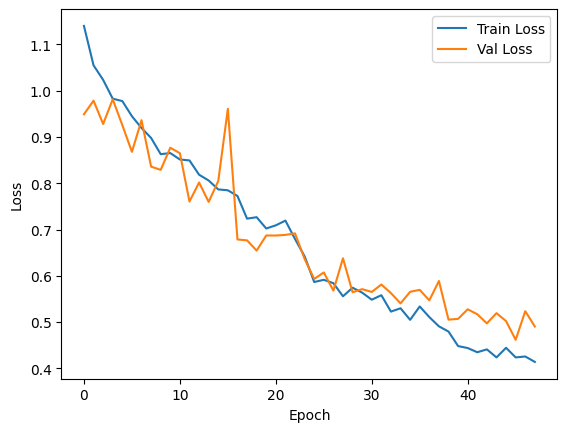

In [20]:
# Loss
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

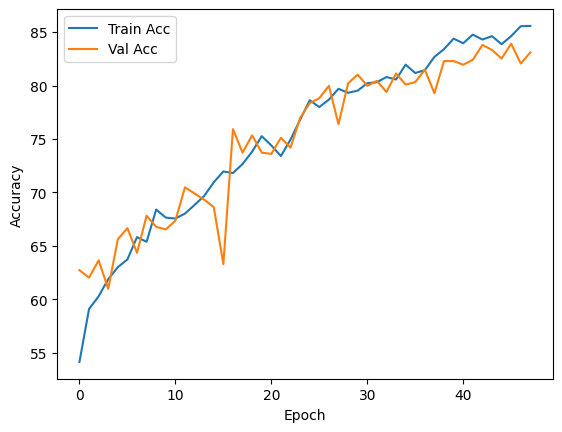

In [21]:
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

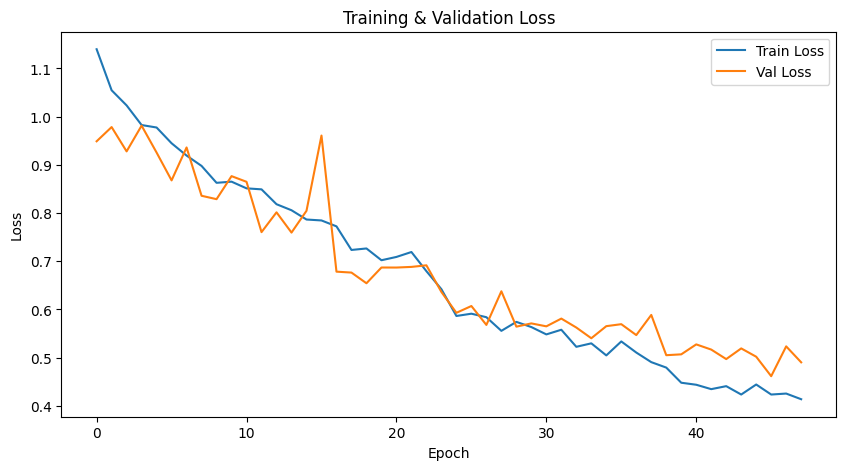

In [23]:
plt.figure(figsize=(10,5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training & Validation Loss")

plt.legend()

plt.show()

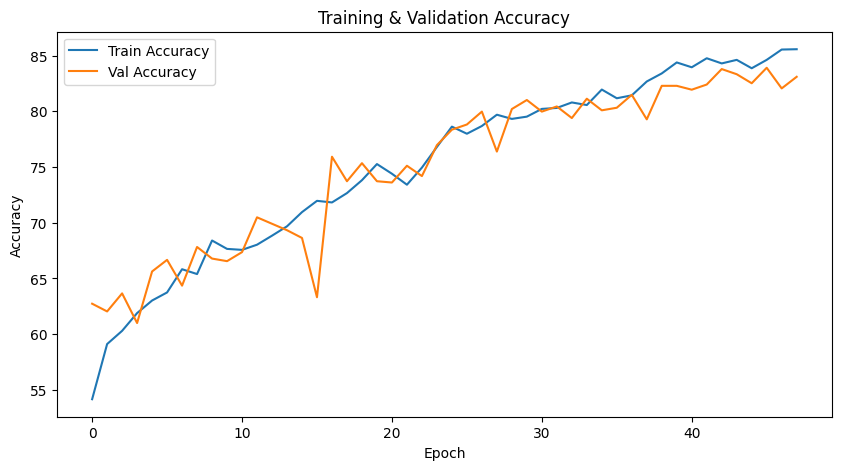

In [24]:
plt.figure(figsize=(10,5))

plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Val Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training & Validation Accuracy")

plt.legend()

plt.show()

In [30]:
model.eval()

all_labels = []
all_preds = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())

        all_preds.extend(predicted.cpu().numpy())

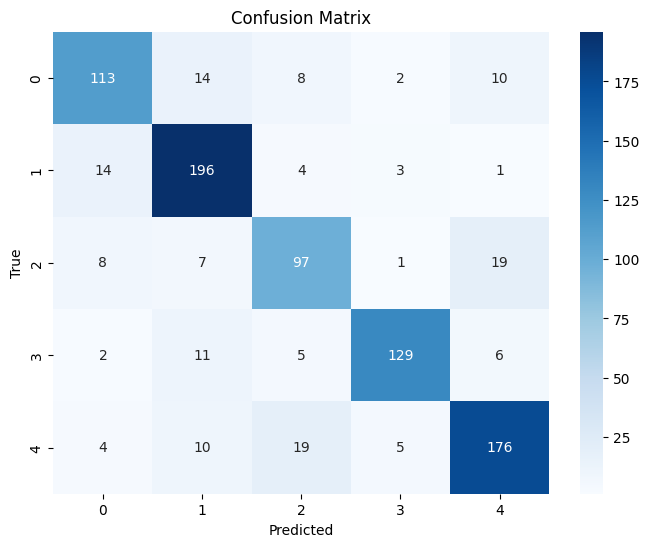

In [31]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title("Confusion Matrix")

plt.show()

In [32]:
print(
    classification_report(
        all_labels,
        all_preds
    )
)

              precision    recall  f1-score   support

           0       0.80      0.77      0.78       147
           1       0.82      0.90      0.86       218
           2       0.73      0.73      0.73       132
           3       0.92      0.84      0.88       153
           4       0.83      0.82      0.83       214

    accuracy                           0.82       864
   macro avg       0.82      0.81      0.82       864
weighted avg       0.82      0.82      0.82       864



## **Tổng kết**